In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

<h2 style='font:32'>Data Understanding</h2>

In [6]:
df1=pd.read_csv('df1_loan.csv')
df1.shape

(500, 15)

In [7]:
df1.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,$5849.0
1,1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,$6091.0
2,2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,$3000.0
3,3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,$4941.0
4,4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,$6000.0


In [9]:
df1.columns

Index(['Unnamed: 0', 'Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income'],
      dtype='object')

In [11]:
df1.drop(columns='Unnamed: 0',inplace=True)

In [12]:
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,$5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,$6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,$3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,$4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,$6000.0


In [37]:
df1.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
495,LP002586,Female,Yes,1,Graduate,No,3326,913.0,105.0,84.0,1.0,Semiurban,Y,$4239.0
496,LP002587,Male,Yes,0,Not Graduate,No,2600,1700.0,107.0,360.0,1.0,Rural,Y,$4300.0
497,LP002588,Male,Yes,0,Graduate,No,4625,2857.0,111.0,12.0,NaN,Urban,Y,$7482.0
498,LP002600,Male,Yes,1,Graduate,Yes,2895,0.0,95.0,360.0,1.0,Semiurban,Y,$2895.0
499,LP002602,Male,No,0,Graduate,No,6283,4416.0,209.0,360.0,0.0,Rural,N,$10699.0


In [13]:
df1.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
Total_Income          object
dtype: object

In [51]:
#i need dependent as int
df1['Dependents'].unique()
## Replace '3+' with 3 and convert to int
df1['Dependents'] = df1['Dependents'].replace('3+', 3)
df1['Dependents'] = pd.to_numeric(df1['Dependents'], errors='coerce')

In [52]:
num_columns = df1.select_dtypes(include=['number'])
num_columns.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,0.0,5849,0.0,NaN,360.0,1.0
1,1.0,4583,1508.0,128.0,360.0,1.0
2,0.0,3000,0.0,66.0,360.0,1.0
3,0.0,2583,2358.0,120.0,360.0,1.0
4,0.0,6000,0.0,141.0,360.0,1.0


In [15]:
df1.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,500.000000,500.000000,482.000000,486.000000,459.000000
mean,5493.644000,1506.307840,144.020747,342.543210,0.843137
std,6515.668972,2134.432188,82.344919,63.834977,0.364068
min,150.000000,0.000000,17.000000,12.000000,0.000000
25%,2874.500000,0.000000,100.000000,360.000000,1.000000
50%,3854.000000,1125.500000,126.500000,360.000000,1.000000
75%,5764.000000,2253.250000,161.500000,360.000000,1.000000
max,81000.000000,20000.000000,700.000000,480.000000,1.000000


In [53]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            500 non-null    object 
 1   Gender             491 non-null    object 
 2   Married            497 non-null    object 
 3   Dependents         488 non-null    float64
 4   Education          500 non-null    object 
 5   Self_Employed      473 non-null    object 
 6   ApplicantIncome    500 non-null    int64  
 7   CoapplicantIncome  500 non-null    float64
 8   LoanAmount         482 non-null    float64
 9   Loan_Amount_Term   500 non-null    float64
 10  Credit_History     459 non-null    float64
 11  Property_Area      500 non-null    object 
 12  Loan_Status        500 non-null    object 
 13  Total_Income       500 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 54.8+ KB


<h2 style='font:32'>2. Data Preprocessing</h2>

In [54]:
#lets handle missing values
df1.isnull().sum()

Loan_ID               0
Gender                9
Married               3
Dependents           12
Education             0
Self_Employed        27
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           18
Loan_Amount_Term      0
Credit_History       41
Property_Area         0
Loan_Status           0
Total_Income          0
dtype: int64

In [23]:
df1['Loan_Amount_Term'].fillna(df1['Loan_Amount_Term'].median(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_11528\2481937099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Loan_Amount_Term'].fillna(df1['Loan_Amount_Term'].median(),inplace=True)


In [24]:
df1['Loan_Amount_Term'].isnull().sum()

np.int64(0)

In [26]:
#lets see the distribution of loan applicants if we have enough samples for success and failure
n_y=df1['Loan_Status'].value_counts()

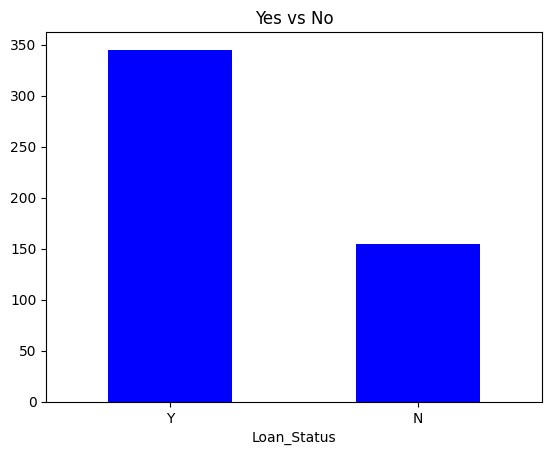

In [36]:
n_y.plot(kind='bar',title='Yes vs No',color='blue')
plt.xlabel('Loan_Status')
plt.xticks(rotation=0)
plt.show()

Inference: Dataset contains a Bias showing more possibility of getting a Loan, but using thumb rule, sample contain enough of the 
two possibilities

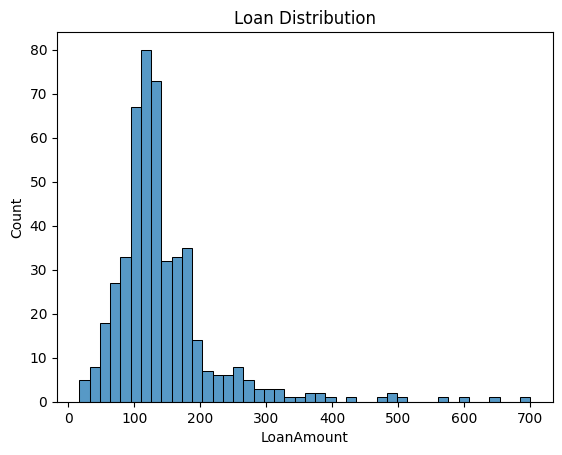

In [55]:
#lets view some of the datasets distribution before filling na, 
sns.histplot(data=df1,x='LoanAmount')
plt.title('Loan Distribution')
plt.show()

In [57]:
#given the presence of skewness it is wise to fill with median 
df1['LoanAmount'].fillna(df1['LoanAmount'].median(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_11528\3893637283.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['LoanAmount'].fillna(df1['LoanAmount'].median(),inplace=True)


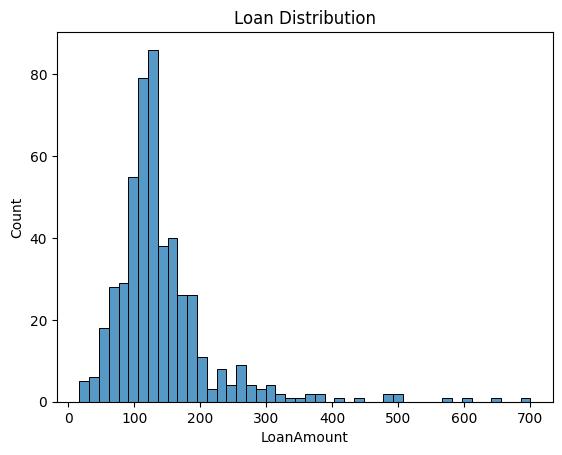

In [58]:
#lets view again
sns.histplot(data=df1,x='LoanAmount')
plt.title('Loan Distribution')
plt.show()

In [59]:
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,126.5,360.0,1.0,Urban,Y,$5849.0
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,$6091.0
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,$3000.0
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,$4941.0
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,$6000.0


In [60]:
df1.isnull().sum()

Loan_ID               0
Gender                9
Married               3
Dependents           12
Education             0
Self_Employed        27
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       41
Property_Area         0
Loan_Status           0
Total_Income          0
dtype: int64

In [61]:
df1.groupby('Loan_Status').Credit_History.value_counts()

Loan_Status  Credit_History
N            1.0                80
             0.0                66
Y            1.0               307
             0.0                 6
Name: count, dtype: int64

# Inference:
Noticed most of the guys who got a loan had a credit history of 1 , lets fill na with that

In [62]:
df1['Credit_History'] = df1.apply(
    lambda x: 1.0 if x['Loan_Status'] == 'Y' and pd.isnull(x['Credit_History']) 
    else x['Credit_History'],
    axis=1
)

In [68]:
df1['Credit_History'].isnull().sum()
df1['Credit_History'].fillna(df1['Credit_History'].mean(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_11528\2343161290.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Credit_History'].fillna(df1['Credit_History'].mean(),inplace=True)


In [69]:
df1['Credit_History'].isnull().sum()

np.int64(0)

In [77]:
df1.groupby('Loan_Status').agg(
    {'Self_Employed':'value_counts',
     'Dependents':'value_counts'})

Self_Employed  Dependents
Loan_Status                               
N           No           134.0         NaN
            Yes           21.0         NaN
Y           No           300.0         NaN
            Yes           45.0         NaN
N           0.0            NaN        88.0
            1.0            NaN        31.0
            2.0            NaN        18.0
            3.0            NaN        15.0
Y           0.0            NaN       200.0
            2.0            NaN        61.0
            1.0            NaN        50.0
            3.0            NaN        25.0

# Inference:
Observed that the modal value for those that got the loan and those who didnt get was No to self employed 

In [79]:
df1['Self_Employed'].fillna('No',inplace=True)
df1['Dependents'].fillna(0.0,inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_11528\541749815.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Dependents'].fillna(0.0,inplace=True)


In [80]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            500 non-null    object 
 1   Gender             491 non-null    object 
 2   Married            497 non-null    object 
 3   Dependents         500 non-null    float64
 4   Education          500 non-null    object 
 5   Self_Employed      500 non-null    object 
 6   ApplicantIncome    500 non-null    int64  
 7   CoapplicantIncome  500 non-null    float64
 8   LoanAmount         500 non-null    float64
 9   Loan_Amount_Term   500 non-null    float64
 10  Credit_History     500 non-null    float64
 11  Property_Area      500 non-null    object 
 12  Loan_Status        500 non-null    object 
 13  Total_Income       500 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 54.8+ KB


In [84]:
df1.dropna(subset=['Gender'],inplace=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 0 to 499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            491 non-null    object 
 1   Gender             491 non-null    object 
 2   Married            488 non-null    object 
 3   Dependents         491 non-null    float64
 4   Education          491 non-null    object 
 5   Self_Employed      491 non-null    object 
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         491 non-null    float64
 9   Loan_Amount_Term   491 non-null    float64
 10  Credit_History     491 non-null    float64
 11  Property_Area      491 non-null    object 
 12  Loan_Status        491 non-null    object 
 13  Total_Income       491 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 57.5+ KB


# 3. Feature Understanding

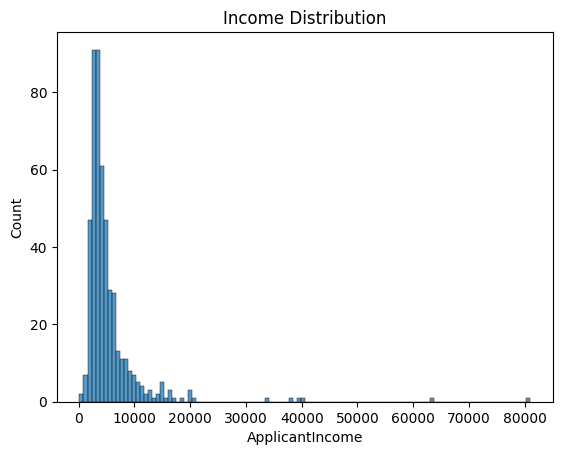

In [85]:
sns.histplot(data=df1,x='ApplicantIncome')
plt.title('Income Distribution')
plt.show()

In [87]:
df1['log_income']=np.log(df1['ApplicantIncome'])

In [88]:
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,log_income
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,126.5,360.0,1.0,Urban,Y,$5849.0,8.674026
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,$6091.0,8.430109
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,$3000.0,8.006368
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,$4941.0,7.856707
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,$6000.0,8.699515


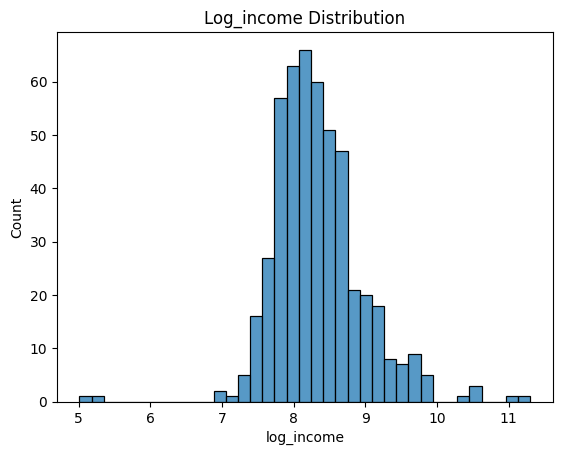

In [89]:
sns.histplot(data=df1,x='log_income')
plt.title('Log_income Distribution')
plt.show()

<Axes: >

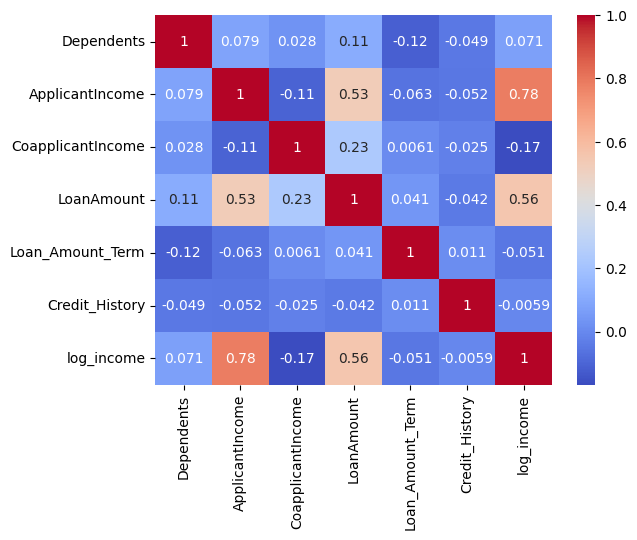

In [90]:
#lets display corr matrix
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')

## Inference:
There is a moderately positive correlation between the log of income and loanAmount

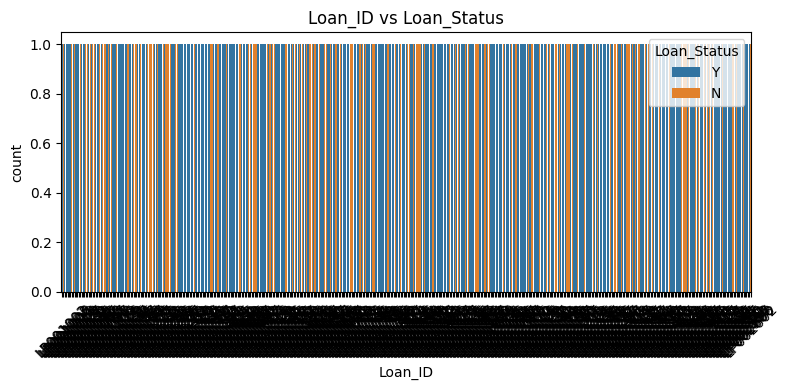

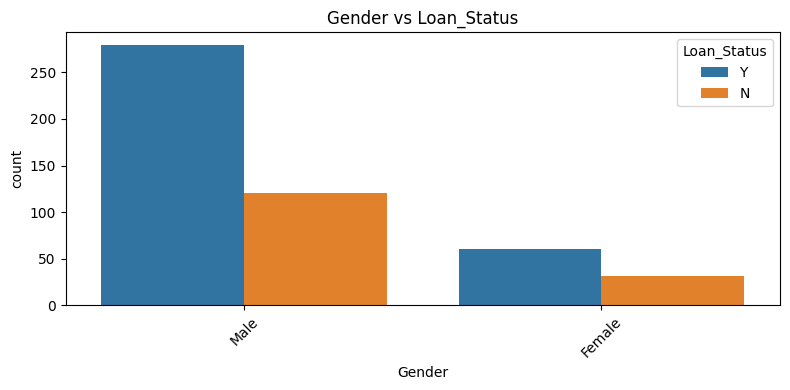

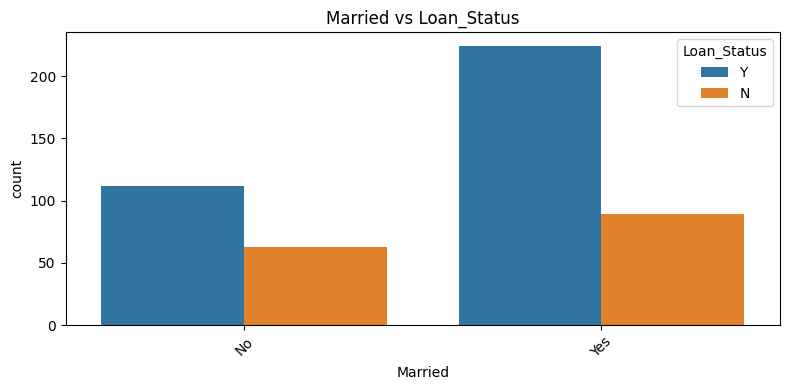

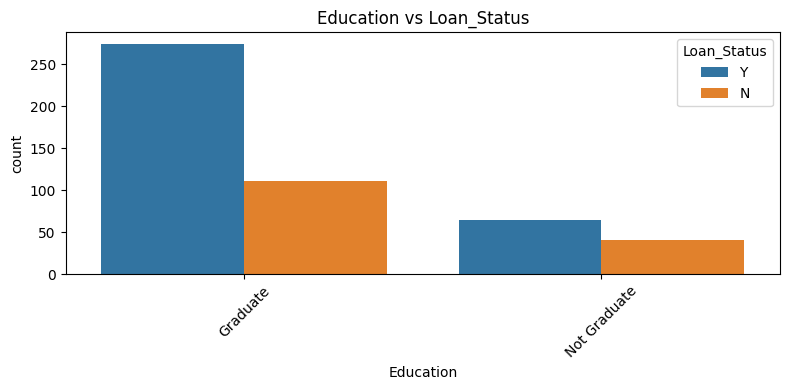

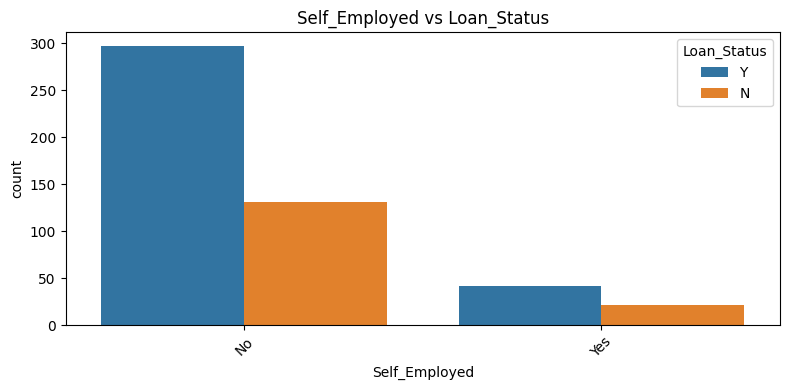

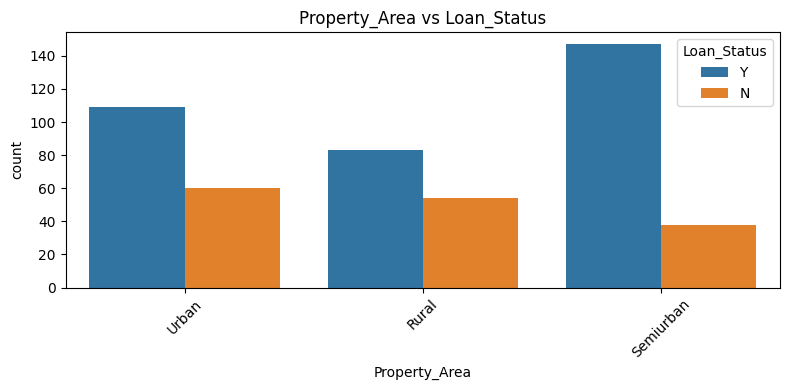

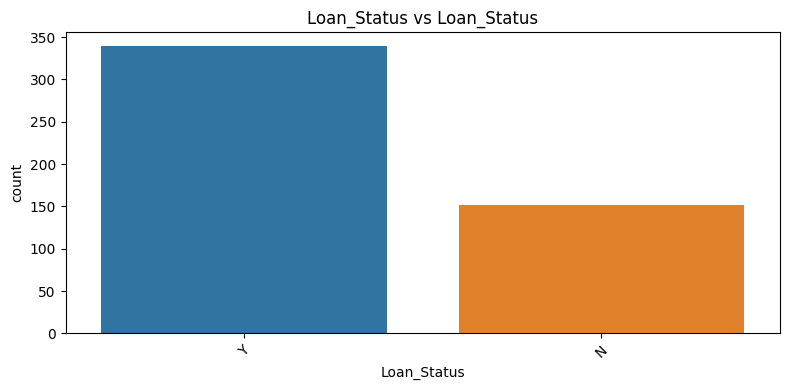

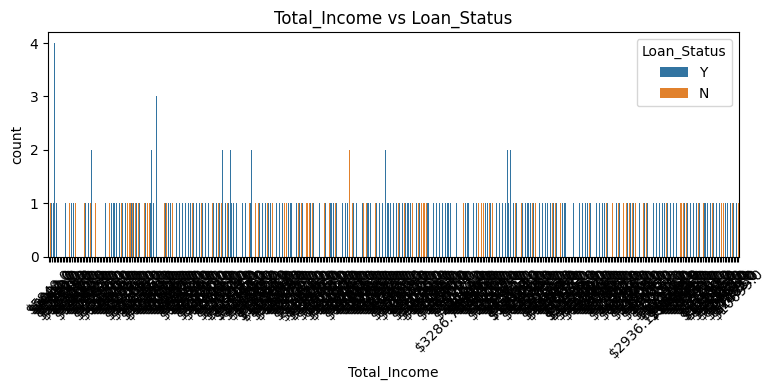

In [92]:
for col in df1.select_dtypes(include='object').columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='Loan_Status', data=df1)
    plt.title(f'{col} vs Loan_Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Inferences:
1. The dataset shows that a larger percentage of Men than Women got the loan although there was a bias of Men and women sampled
2. The dataset also showed that it is more likely to get a loan if you are married than if you are not
3. The dataset also showed that you are more likely to get a loan if you are a graduate
4. Property Area is not a really important metrics to get a loan but people who live in the semiurban are more likely to get a loan than the rural and urban